# Анализ производных признаков


Цель данного ноутбука - проверить распределения, пропуски и аналитическую полезность производных признаков, сформированных на предыдущем этапе.


## Загрузка библиотек и установка настроек


In [20]:
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("viridis")
pd.set_option("display.float_format", "{:.4f}".format)


## Загрузка аналитического набора данных


In [21]:
listings = pd.read_parquet("../data/processed/listings_analytics.parquet")


## Служебные структуры


In [23]:
NUMERIC_COLUMNS = [
    "availability_ratio",
    "review_intensity",
    "log_price",
]

CATEGORICAL_COLUMNS = [
    "has_last_review",
    "has_price",
    "is_price_outlier",
    "host_size_segment",
]


In [24]:
featured_listings = listings[NUMERIC_COLUMNS + CATEGORICAL_COLUMNS]


### Проверка пропусков производных признаков


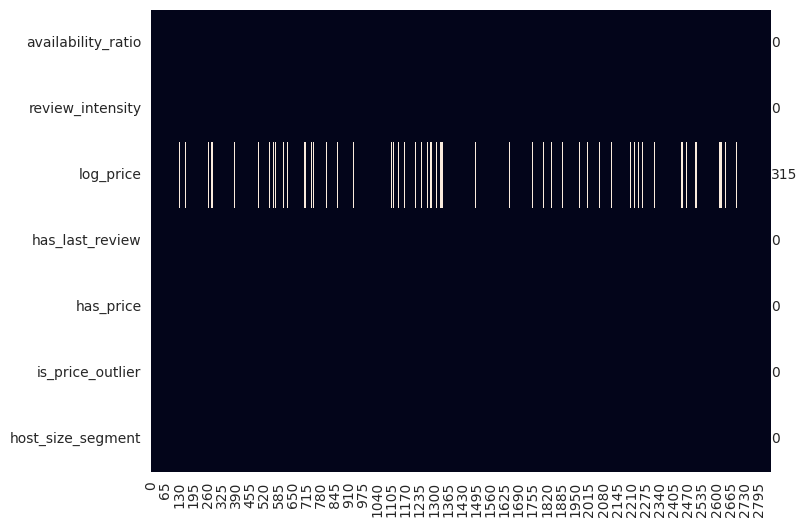

In [25]:
missing_counts = featured_listings.isna().sum()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(featured_listings.isna().T, cbar=False, ax=ax)

for i, val in enumerate(missing_counts):
    ax.text(featured_listings.shape[0], i + 0.5, val, va="center")

plt.show()


Все производные признаки, кроме `log_price`, заполнены полностью. Это ожидаемо, поскольку исходный `price` имеет пропущенные значения.


## Одномерный анализ производных признаков


### Числовые производные признаки


#### Распределения и базовые статистики


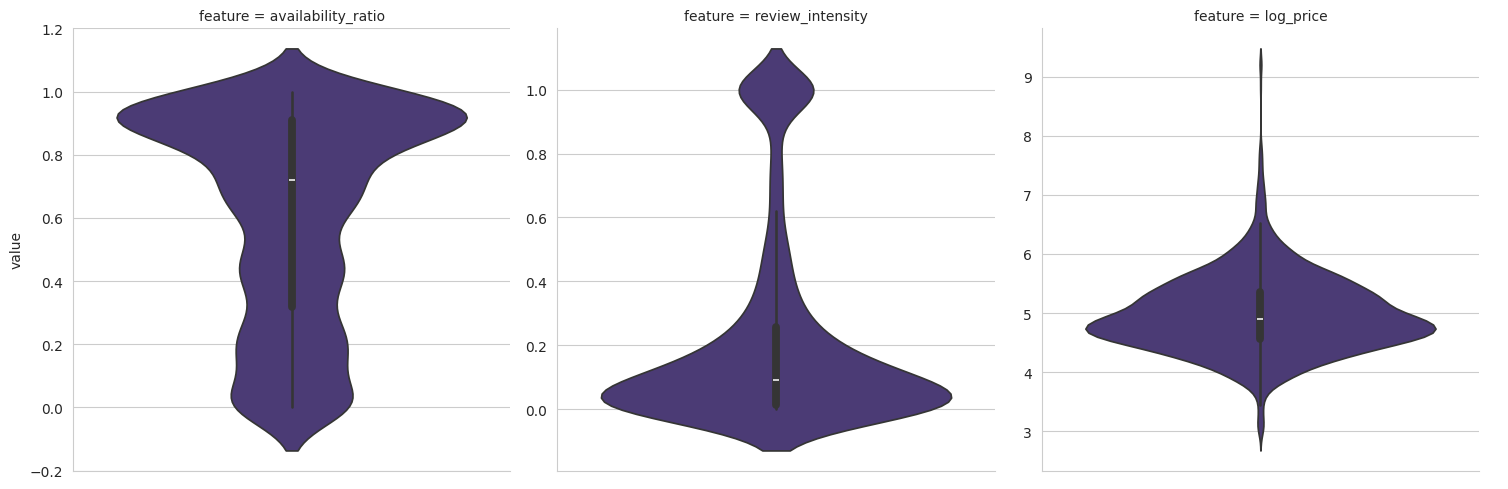

In [26]:
sns.catplot(
    data=featured_listings[NUMERIC_COLUMNS].melt(
        var_name="feature", value_name="value"
    ),
    y="value",
    kind="violin",
    col="feature",
    col_wrap=3,
    sharey=False,
)


In [27]:
listings[NUMERIC_COLUMNS].describe()


,availability_ratio,review_intensity,log_price
count,2852.0000,2852.0000,2537.0000
mean,0.6125,0.2270,4.9798
std,0.3349,0.3159,0.6549
min,0.0000,0.0000,2.9444
25%,0.3178,0.0135,4.5643
50%,0.7205,0.0927,4.8978
75%,0.9096,0.2585,5.3566
max,1.0000,1.0000,9.2103


`availability_ratio` смещено к высоким значениям: большинтво объектов доступны круглый год.   
`review_intensity` для основной массы объектов остаётся низким.     
`log_price` после преобразования становится заметно компактнее, хотя всё ещё сохраняет правый хвост.


#### Экстремальные наблюдения


In [28]:
for col in [
    "availability_ratio",
    "review_intensity",
    "log_price",
]:
    print(f"\n{col} TOP 5")
    display(listings.nlargest(5, col))

    print(f"{col} BOTTOM 5")
    display(listings.nsmallest(5, col))



availability_ratio TOP 5


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_last_review,has_price,is_price_outlier,host_size_segment,availability_ratio,review_intensity,log_price
45,2569529,Downtown Asheville 2 bed/2bath unit for rent,8671251,Heather,28801,35.6011,-82.5559,Entire home/apt,85.0000,180,...,1,365,0,True,True,False,Individual host,1.0000,0.0000,4.4543
55,3445336,Bungalow in Downtown Asheville,17363326,Michael,28801,35.5918,-82.5463,Entire home/apt,NaN,30,...,2,365,0,False,False,False,Experienced host,1.0000,0.0000,NaN
109,7001873,Wren's Nest Studio near River Arts,11298793,Miriam,28806,35.5950,-82.5886,Entire home/apt,69.0000,730,...,1,365,0,True,True,False,Individual host,1.0000,0.0000,4.2485
134,8593492,Cabin 400 sq all for you.,45217605,Gathai,28732,35.4411,-82.5219,Private room,372.0000,2,...,2,365,0,True,True,False,Experienced host,1.0000,0.0000,5.9216
244,15845920,The Treehouse Below - Private Apartment / Entr...,46300912,Robin,28806,35.5723,-82.6049,Entire home/apt,270.0000,1,...,1,365,0,True,True,False,Individual host,1.0000,0.0000,5.6021


availability_ratio BOTTOM 5


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_last_review,has_price,is_price_outlier,host_size_segment,availability_ratio,review_intensity,log_price
6,436476,"8 min Walk to DT AVL! Hip, Chic % Sparkling CLEAN",478398,Heidi,28801,35.6015,-82.5604,Entire home/apt,NaN,2,...,3,0,0,True,False,False,Experienced host,0.0000,0.0000,NaN
26,1332684,Sweet Studio - Walk West Asheville,2799158,Kari,28806,35.5818,-82.5927,Entire home/apt,NaN,30,...,1,0,2,True,False,False,Individual host,0.0000,0.0039,NaN
50,3225871,Little forest 5 mins from airport,16293519,Chun,28732,35.4410,-82.5057,Entire home/apt,NaN,1,...,1,0,0,True,False,False,Individual host,0.0000,0.0000,NaN
54,3405282,The Cabin In Grove Park,17173574,Scott & Catherine,28801,35.6121,-82.5441,Entire home/apt,NaN,30,...,1,0,0,True,False,False,Individual host,0.0000,0.0000,NaN
81,5344892,Peaceful Mountainside Living,5912974,Daniel,28805,35.6245,-82.4934,Entire home/apt,NaN,30,...,1,0,0,True,False,False,Individual host,0.0000,0.0000,NaN



review_intensity TOP 5


...

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_last_review,has_price,is_price_outlier,host_size_segment,availability_ratio,review_intensity,log_price
3,246315,Asheville Dreamer's Cabin,1292070,Annie,28805,35.5962,-82.5063,Private room,62.0000,7,...,3,70,0,True,True,False,Experienced host,0.1918,0.0000,4.1431
5,427497,Luxurious Mountain Guest Suite Apartment,1909922,Milan,28803,35.4909,-82.4860,Entire home/apt,148.0000,2,...,1,359,0,True,True,False,Individual host,0.9836,0.0000,5.0039
6,436476,"8 min Walk to DT AVL! Hip, Chic % Sparkling CLEAN",478398,Heidi,28801,35.6015,-82.5604,Entire home/apt,NaN,2,...,3,0,0,True,False,False,Experienced host,0.0000,0.0000,NaN
12,723349,#2 Blue Ridge Room at Oakland Cottage B&B,3736218,Mary,28801,35.5747,-82.5571,Private room,247.0000,2,...,7,325,0,True,True,False,Industrial host,0.8904,0.0000,5.5134
15,846221,Town and Mountain Peaceful Retreat,4418555,Bart,28804,35.6436,-82.5114,Entire home/apt,169.0000,2,...,1,178,0,True,True,False,Individual host,0.4877,0.0000,5.1358



log_price TOP 5


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_last_review,has_price,is_price_outlier,host_size_segment,availability_ratio,review_intensity,log_price
2768,1450886572499190369,Kasa | Queen Room | Asheville,88566861,Kasa,28801,35.6008,-82.5444,Entire home/apt,9999.0000,1,...,5,263,3,True,True,True,Industrial host,0.7205,1.0000,9.2103
2770,1451419550411824711,Kasa | Double Twin Room | Asheville,88566861,Kasa,28801,35.6006,-82.5441,Entire home/apt,9999.0000,1,...,5,277,8,True,True,True,Industrial host,0.7589,1.0000,9.2103
2776,1452315568921110412,Kasa | Queen Room with Kitchenette | Asheville,88566861,Kasa,28801,35.6020,-82.5437,Private room,9999.0000,1,...,5,279,8,True,True,True,Industrial host,0.7644,1.0000,9.2103
2594,1339091513653409760,Asheville River Cabins,477251437,Asheville River Cabins,28704,35.4903,-82.5722,Entire home/apt,6847.0000,1,...,8,358,0,False,True,True,Industrial host,0.9808,0.0000,8.8317
2590,1334016503347045444,Test- Do Not Book,671103351,Richa,28806,35.5847,-82.5921,Entire home/apt,2558.0000,1,...,1,365,0,False,True,True,Individual host,1.0000,0.0000,7.8474


log_price BOTTOM 5


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,...,calculated_host_listings_count,availability_365,number_of_reviews_ltm,has_last_review,has_price,is_price_outlier,host_size_segment,availability_ratio,review_intensity,log_price
502,25138871,Tent Site #1 @The Baying Hound Campground,151279507,Amanda Elizabeth,28806,35.6116,-82.6052,Entire home/apt,18.0000,1,...,20,90,2,True,True,False,Industrial host,0.2466,0.0198,2.9444
488,24697002,Tent Site #2 @The Baying Hound Campground,151279507,Amanda Elizabeth,28806,35.6129,-82.6038,Entire home/apt,20.0000,1,...,20,176,0,True,True,False,Industrial host,0.4822,0.0000,3.0445
533,26634224,Tent Site #4 @The Baying Hound Campground,151279507,Amanda Elizabeth,28806,35.6115,-82.6052,Entire home/apt,20.0000,1,...,20,176,3,True,True,False,Industrial host,0.4822,0.0375,3.0445
966,42980053,Tent Site #6 @The Baying Hound Campground,151279507,Amanda Elizabeth,28806,35.6122,-82.6043,Entire home/apt,20.0000,1,...,20,358,2,True,True,False,Industrial host,0.9808,0.0267,3.0445
968,42981397,Hammock Site @The Baying Hound Campground,151279507,Amanda Elizabeth,28806,35.6123,-82.6050,Entire home/apt,20.0000,1,...,20,364,2,True,True,False,Industrial host,0.9973,0.0741,3.0445


Экстремумы показывают три разных типа поведения.    
`availability_ratio` принимает значения от полной недоступности до доступности весь год;    
`review_intensity` достигает *1* у объявлений, чьи все накопленные отзывы пришлись на последний год;    
`log_price` по-прежнему выделяет сверхдорогие объекты с ценами *9999* долларов, но уже без доминирования абсолютного масштаба.


### Категориальные производные признаки


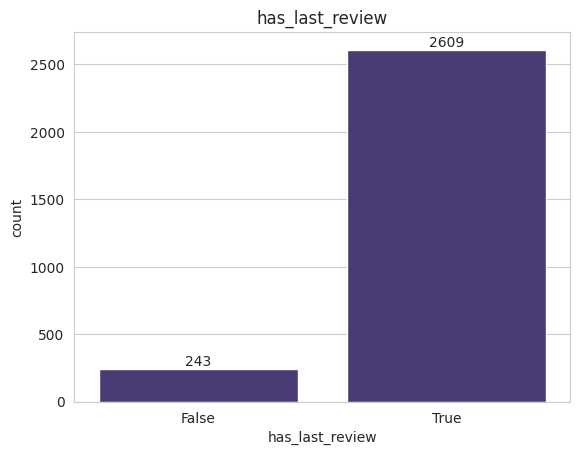

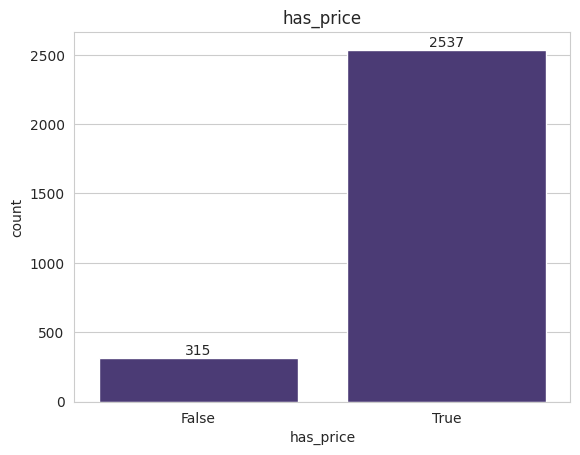

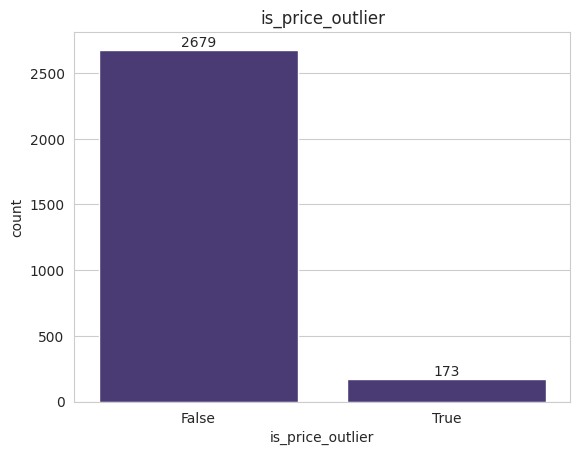

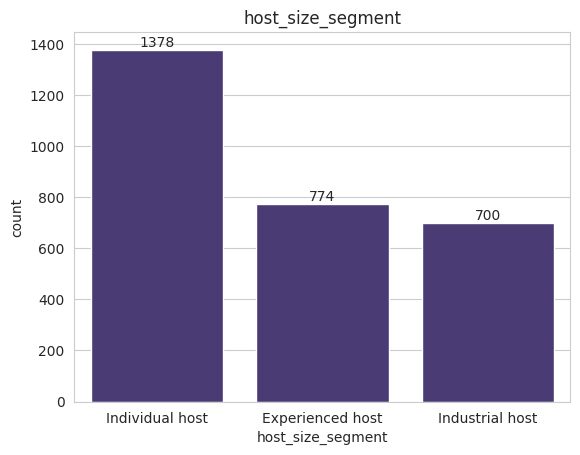

In [29]:
for col in CATEGORICAL_COLUMNS:
    ax = sns.countplot(data=listings, x=col)

    for container in ax.containers:
        ax.bar_label(container)

    plt.title(col)
    plt.show()


Категориальные производные поля остаются интерпретируемыми и достаточно информативными.


## Промежуточные выводы
1. Производные признаки оказываются пригодными для дальнейшего аналитического слоя.
2. Почти все новые признаки заполнены полностью, единственный пропуск в `log_price` наследует пропуски исходной цены.
